In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

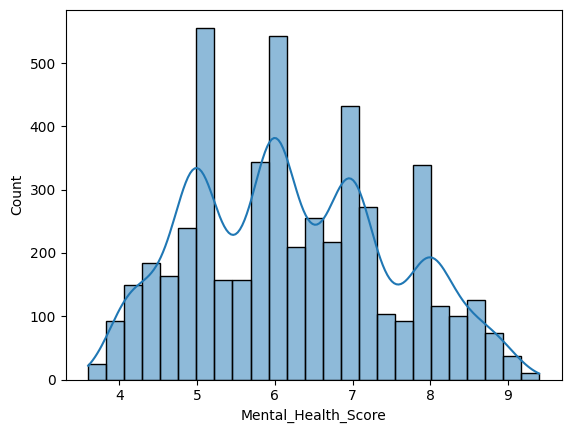

In [8]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

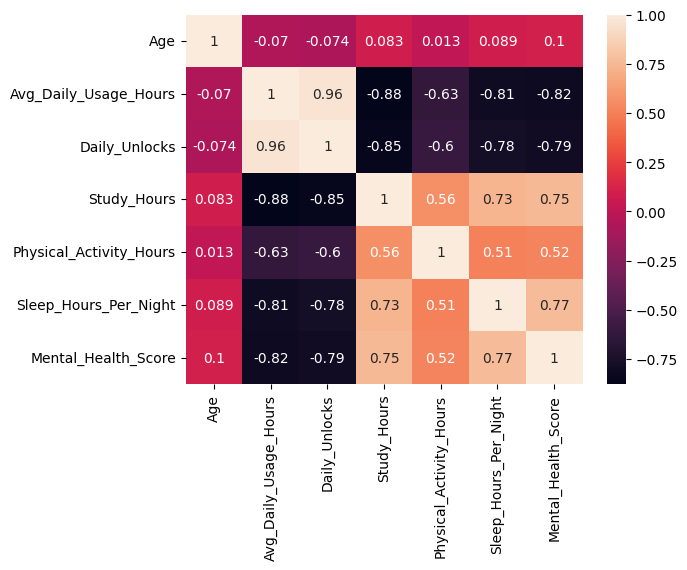

In [9]:
sns.heatmap(df.corr(numeric_only = True),annot=True)

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

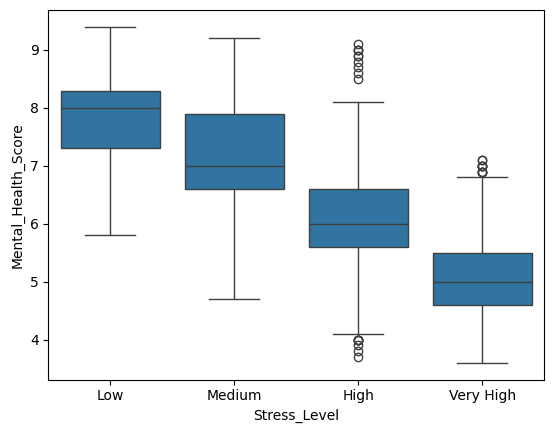

In [11]:
order = ['Low', 'Medium', 'High','Very High']
sns.boxplot(x='Stress_Level',y = 'Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

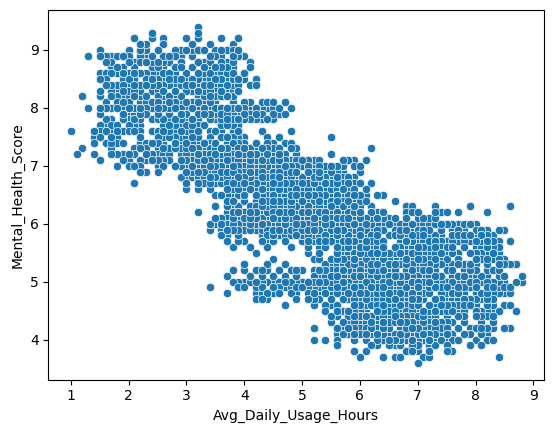

In [12]:
sns.scatterplot(x ='Avg_Daily_Usage_Hours',y = 'Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

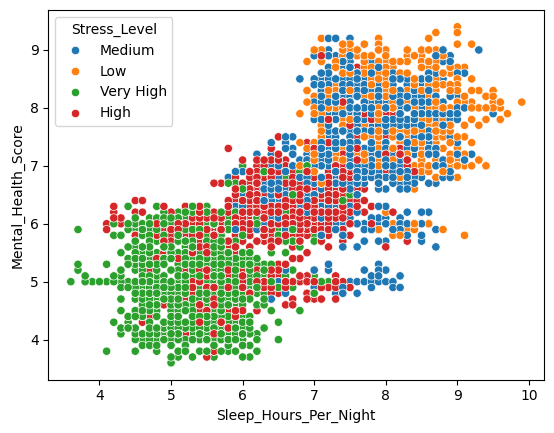

In [13]:
sns.scatterplot(x ='Sleep_Hours_Per_Night',y = 'Mental_Health_Score',hue='Stress_Level',data=df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

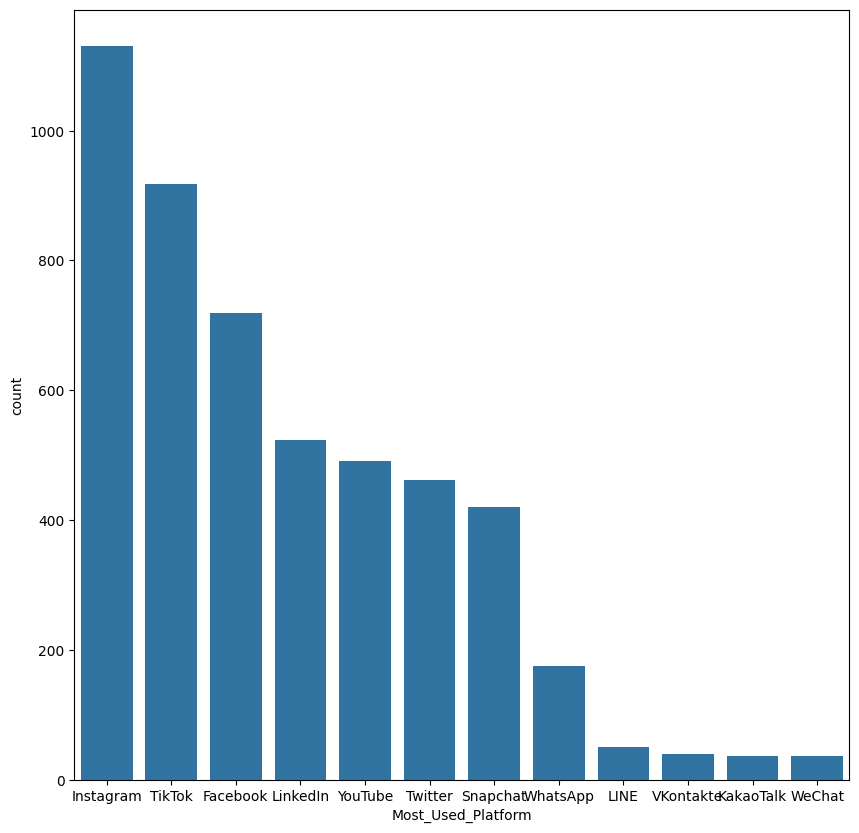

In [14]:
plt.figure(figsize=(10,10))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

In [15]:
num_features = df.select_dtypes(include=['number'])
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = num_features[(num_features < lower_bound) | (num_features > upper_bound)]
outliers_count = outliers.count()
print(outliers_count)

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [16]:
#1 To drop duplicates AND guarantee an independent dataset
df = df.drop_duplicates().copy()

#2 Converting the negative or unrealistic value to realistic value to zero
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [18]:
num_cols = df.select_dtypes(include=['number'])
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [19]:
Top_countries = df['Country'].value_counts().index[:10].tolist()

In [20]:
def grp_countries(Country):
  if Country in Top_countries:
    return Country
  else:
    return 'Other'

In [21]:
df['Grouped_Country'] = df['Country'].apply(grp_countries)

In [22]:
df['Grouped_Country'].value_counts()

,count
Grouped_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [23]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_Country'],
      dtype='object')

In [24]:
from sklearn.model_selection import train_test_split

skewed_cols    = ['Study_Hours']
other_num_cols = ["Age","Avg_Daily_Usage_Hours","Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_cols   = ["Stress_Level"]
nominal_cols   = ["Gender","Academic_Level","Most_Used_Platform","Purpose_Of_Use","Grouped_Country"]

feature_cols  = skewed_cols + other_num_cols + ordinal_cols + nominal_cols
X = df[feature_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.30, random_state=42)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,FunctionTransformer,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skewed Features
skew_pipelines = Pipeline(steps=[
    ('log_transformer',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

#2. numeric feature
plain_numeric_pipelines = Pipeline(steps=[
    ('scaler',StandardScaler())
])

#3. ordinal
ordinal_pipelines = Pipeline(steps=[
    ('encode' , OrdinalEncoder(categories = [['Low','Medium','High','Very High']]))
])

#4. Nominal features
nominal_pipelines = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('skew_pipelines',skew_pipelines,skewed_cols),
    ('plain_numeric_pipelines',plain_numeric_pipelines,other_num_cols),
    ('ordinal_pipelines',ordinal_pipelines,ordinal_cols),
    ('nominal_pipelines',nominal_pipelines,nominal_cols)
])


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

lr_pipelines = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipelines.fit(X_train,y_train)
lr_preds = lr_pipelines.predict(X_test)
lr_r2_train = lr_pipelines.predict(X_train)


lr_r2_testing = r2_score(y_test,lr_preds)
lr_r2_training = r2_score(y_train,lr_r2_train)
lr_mae = mean_absolute_error(y_test,lr_preds)

print(f"Accuracy of training set is {lr_r2_training}")
print(f"Accuracy of testing set is {lr_r2_testing}")
print(f"Mean Absolute Error is {lr_mae}")

Accuracy of training set is 0.7236771199387538
Accuracy of testing set is 0.7397944617433021
Mean Absolute Error is 0.5361775634720181


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_pipelines = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state=42))
])

rf_pipelines.fit(X_train,y_train)
rf_preds = rf_pipelines.predict(X_test)
rf_r2_train = rf_pipelines.predict(X_train)


rf_r2_training = r2_score(y_train,rf_r2_train)
rf_r2_testing = r2_score(y_test,rf_preds)
rf_mae = mean_absolute_error(y_test,rf_preds)

print(f"Accuracy of training set is {rf_r2_training}")
print(f"Accuracy of testing set is {rf_r2_testing}")
print(f"Mean Absolute Error is {rf_mae}")



Accuracy of training set is 0.9808287942404612
Accuracy of testing set is 0.8775888638668996
Mean Absolute Error is 0.34722113333333343


In [30]:
from sklearn.model_selection import RandomizedSearchCV


# Hyperparameter grid for Random Forest
param_grid = {
    'random forest__n_estimators': [100, 200, 300],
    'random forest__max_depth': [5, 10, 15],
    'random forest__min_samples_split': [2, 5, 10],
    'random forest__min_samples_leaf': [1, 2, 4]
}

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_pipelines,
    param_distributions = param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)







RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipelines',
                                                                               Pipeline(steps=[('log_transformer',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_pipelines',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_Country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [31]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [33]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"R2 score for random forest after hyperparameter tuning {r2_score(y_test,rf_best_preds)}")
print(f"Mean absolute error for random forest after hyperparameter tuning {mean_absolute_error(y_test,rf_best_preds)}")

R2 score for random forest after hyperparameter tuning 0.8650140569761653
Mean absolute error for random forest after hyperparameter tuning 0.3689015766630922


In [35]:
from sklearn.metrics import mean_squared_error

# Initialize a dictionary to store model results
model_results = {}

# Linear Regression Model Metrics
model_results['Linear Regression'] = {
    'R2 (Testing)': lr_r2_testing,
    'R2 (Training)': lr_r2_training,
    'MAE': lr_mae,
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_preds))
}

# Random Forest Model (initial) Metrics
model_results['Random Forest (Initial)'] = {
    'R2 (Testing)': rf_r2_testing,
    'R2 (Training)': rf_r2_training,
    'MAE': rf_mae,
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds))
}

# Random Forest Model (after hyperparameter tuning) Metrics
rf_best_r2_train_preds = rf_best_pipeline.predict(X_train)
rf_best_r2_training = r2_score(y_train, rf_best_r2_train_preds)

model_results['Random Forest (Tuned)'] = {
    'R2 (Testing)': r2_score(y_test, rf_best_preds),
    'R2 (Training)': rf_best_r2_training,
    'MAE': mean_absolute_error(y_test, rf_best_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_best_preds))
}

# Convert to DataFrame for better visualization
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df.index.name = 'Model'

print(results_df)

                         R2 (Testing)  R2 (Training)       MAE      RMSE
Model                                                                   
Linear Regression            0.739794       0.723677  0.536178  0.676032
Random Forest (Initial)      0.877589       0.980829  0.347221  0.463681
Random Forest (Tuned)        0.865014       0.954703  0.368902  0.486915


In [36]:
import joblib
joblib.dump(rf_pipelines,'Mental_Health_Model.pkl')


['Mental_Health_Model.pkl']